# Regresión Logística
## Predicción de Nivel de Riesgo de Meningitis

**Dataset:** Meningitis Dataset  
**Fuente:** Local CSV

## Variable objetivo (Y)
`risk_encoded` — Nivel de riesgo (1=High Risk, 0=Moderate/Low Risk)

## Features seleccionadas (n=8)

| # | Feature | Descripción | Justificación |
|---|---|---|---|
| 1 | `Age` | Edad del paciente | Factor demográfico importante |
| 2 | `WBC_Count` | Conteo de glóbulos blancos en LCR | Indicador de infección |
| 3 | `Protein_Level` | Nivel de proteína en LCR | Alta proteína indica gravedad |
| 4 | `Glucose_Level` | Nivel de glucosa en LCR | Baja glucosa indica bacteriana |
| 5 | `Hemoglobin` | Nivel de hemoglobina | Estado general del paciente |
| 6 | `WBC_Blood_Count` | Conteo de glóbulos blancos en sangre | Respuesta inmune sistémica |
| 7 | `Platelets` | Conteo de plaquetas | Indicador de coagulación |
| 8 | `CRP_Level` | Proteína C reactiva | Marcador de inflamación |

## Columnas descartadas

| Columna | Razón |
|---|---|
| `Patient_ID` | Identificador — sin relación con diagnóstico |
| `Gender` | Categórica — requiere encoding |
| `Pathogen_Present` | Categórica |
| `Diagnosis` | Categórica |
| `Outcome` | Filtrado de información |

## Modelo a implementar
**Regresión Logística** para clasificación binaria

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot

## 1. Carga del Dataset

Se carga el dataset de meningitis desde CSV.
Se seleccionan features numéricas clínicas.
Se rellenan nulos con la mediana.

In [ ]:
data = pd.read_csv('mening missing 12.csv')
data['risk_encoded'] = (data['Risk_Level'] == 'High Risk').astype(int)
FEATURES = [
    'Age',
    'WBC_Count',
    'Protein_Level',
    'Glucose_Level',
    'Hemoglobin',
    'WBC_Blood_Count',
    'Platelets',
    'CRP_Level',
]
TARGET = 'risk_encoded'
for col in FEATURES:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())
X = data[FEATURES].values.astype(np.float64)
y = data[TARGET].values.astype(np.float64)
m = y.size
print(f'Dimensiones dataset : {data.shape}')
print(f'X shape             : {X.shape}')
print(f'y shape             : {y.shape}')
print(f'm                   : {m:,}')
print(f'n features          : {len(FEATURES)}')

Dimensiones dataset : (1200, 15)
X shape             : (1200, 8)
y shape             : (1200,)
m                   : 1,200
n features          : 8


## 2. Exploración del Dataset

Se revisan estadísticas básicas para entender la distribución
de los datos antes de entrenar el modelo.

In [ ]:
print('=== Información general ===')
data.info()
print()
print('=== Estadísticas básicas ===')
data[FEATURES + [TARGET]].describe()

In [5]:
def plotData(X, y):

    fig = pyplot.figure()
    pos = y == 1
    neg = y == 0

    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


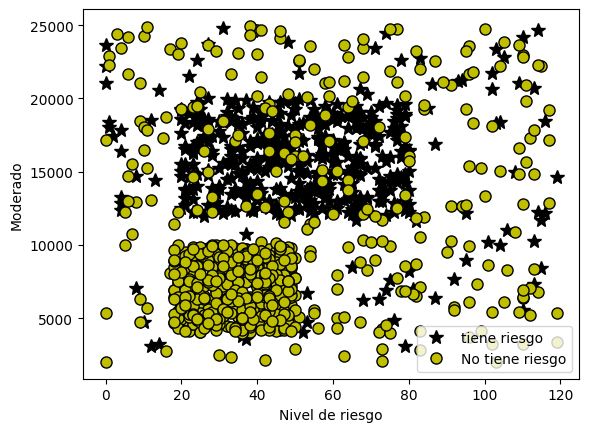

In [ ]:
plotData(X, y)
pyplot.xlabel(FEATURES[0])
pyplot.ylabel(FEATURES[1])
pyplot.legend(['High Risk (1)', 'Other (0)'])
pyplot.show()

In [ ]:
np.random.seed(42)
indices = np.random.permutation(m)
split = int(0.75 * m)
idx_train = indices[:split]
idx_val = indices[split:]
X_train = X[idx_train]
y_train = y[idx_train]
X_val = X[idx_val]
y_val = y[idx_val]
print(f'm_train: {y_train.size:,}')
print(f'm_val  : {y_val.size:,}')

In [ ]:
def sigmoid(z):
    z = np.array(z)
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma = np.where(sigma == 0, 1.0, sigma)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_norm, mu, sigma = featureNormalize(X_train)
X_val_norm = (X_val - mu) / sigma

In [ ]:
m_train, n = X_train_norm.shape
X_train_i = np.concatenate([np.ones((m_train, 1)), X_train_norm], axis=1)
m_val = X_val_norm.shape[0]
X_val_i = np.concatenate([np.ones((m_val, 1)), X_val_norm], axis=1)
print(X_train_i.shape, y_train.shape)
print(X_val_i.shape, y_val.shape)